<a href="https://colab.research.google.com/github/Zafar488/Portfolio/blob/main/MaternalGuard_3_Auto_Datasets_Colab_FIXED_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MaaHifazat AI — MaternalGuard

## Complete Google Colab Workflow Using Only Automatically Downloadable Public Datasets

This notebook uses three public sources that Colab can download automatically:

1. **UCI Maternal Health Risk — Bangladesh**
2. **Tanzania Maternal Health Risks Stratification (MHRS) — Zenodo**
3. **Maternal Health and High-Risk Pregnancy — Zenodo**

No PhysioNet account, CITI training, manual upload, Kaggle token, or restricted dataset is required.

## Harmonized target

The sources do not all use identical class definitions. Therefore, the shared production target is:

- `0 = not_high_risk`
- `1 = high_risk`

For sources with three classes, `low` and `mid/medium` are mapped to `not_high_risk`, while `high` is mapped to `high_risk`.

## Workflow

- Automatic dataset download
- Schema inspection and automatic column mapping
- Unit harmonization
- Missing-value and outlier handling
- Source provenance tracking
- Duplicate and conflicting-label detection
- Leakage-safe feature engineering
- Group-safe train/test split
- Logistic Regression, Random Forest, Extra Trees and XGBoost
- Cross-validation
- Hyperparameter tuning
- High-risk recall optimization
- Probability calibration
- Held-out-source evaluation
- Leave-one-source-out evaluation
- Feature importance and error analysis
- Final `.joblib` export
- Model card
- FastAPI-ready inference code

> Research and hackathon prototype only. It is not an autonomous diagnostic medical device.

## Step 1 — Install packages

In [1]:
%%capture
!pip install -U \
    "pandas>=2.0" \
    "numpy>=1.24" \
    "scipy>=1.10" \
    "matplotlib>=3.7" \
    "scikit-learn>=1.4,<2.0" \
    "xgboost>=2.0,<4.0" \
    "ucimlrepo>=0.0.7" \
    "openpyxl>=3.1" \
    "pyarrow>=15.0" \
    "joblib>=1.3" \
    "requests>=2.31" \
    "fastapi>=0.110" \
    "uvicorn>=0.27" \
    "pydantic>=2.6"

## Step 2 — Imports and configuration

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import random
import re
import shutil
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn
import xgboost

from scipy.stats import randint, loguniform, uniform
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedGroupKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
FAST_MODE = True
SEARCH_ITERATIONS = 15 if FAST_MODE else 50
CV_SPLITS = 5
TARGET_HIGH_RISK_RECALL = 0.90
MODEL_VERSION = "3.0.0"

np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/maternalguard")
RAW_DIR = ROOT / "raw"
PROCESSED_DIR = ROOT / "processed"
ARTIFACT_DIR = ROOT / "artifacts"

for folder in [RAW_DIR, PROCESSED_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Project root:", ROOT)

Python: 3.12.13
pandas: 3.0.3
scikit-learn: 1.9.0
XGBoost: 3.3.0
Project root: /content/maternalguard


## Step 3 — Dataset registry

Zenodo record IDs are stable identifiers. The notebook queries the Zenodo API and obtains the current file URL automatically.

In [2]:
DATASET_REGISTRY = {
    "uci_bangladesh": {
        "type": "uci",
        "id": 863,
        "expected_file": None,
        "license": "CC BY 4.0",
    },
    "tanzania_mhrs": {
        "type": "zenodo",
        "id": "15309733",
        "expected_file": "maternal_dataset_csv.csv",
        "license": "CC BY 4.0",
    },
    "zenodo_high_risk": {
        "type": "zenodo",
        "id": "14537882",
        "expected_file": "Book2.xlsx",
        "license": "CC BY 4.0",
    },
}

print(json.dumps(DATASET_REGISTRY, indent=2))

{
  "uci_bangladesh": {
    "type": "uci",
    "id": 863,
    "expected_file": null,
    "license": "CC BY 4.0"
  },
  "tanzania_mhrs": {
    "type": "zenodo",
    "id": "15309733",
    "expected_file": "maternal_dataset_csv.csv",
    "license": "CC BY 4.0"
  },
  "zenodo_high_risk": {
    "type": "zenodo",
    "id": "14537882",
    "expected_file": "Book2.xlsx",
    "license": "CC BY 4.0"
  }
}


## Step 4 — Automatic download helpers

In [3]:
def stream_download(
    url: str,
    output_path: Path,
    expected_md5: str | None = None,
) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        print("Already downloaded:", output_path.name)
        return output_path

    with requests.get(url, stream=True, timeout=300) as response:
        response.raise_for_status()
        with output_path.open("wb") as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)

    if expected_md5:
        digest = hashlib.md5(output_path.read_bytes()).hexdigest()
        if digest.lower() != expected_md5.lower():
            output_path.unlink(missing_ok=True)
            raise ValueError(
                f"MD5 mismatch for {output_path.name}: {digest}"
            )

    print("Downloaded:", output_path.name)
    return output_path


def download_zenodo_file(
    record_id: str,
    expected_filename: str,
) -> Path:
    metadata_url = f"https://zenodo.org/api/records/{record_id}"
    response = requests.get(metadata_url, timeout=90)
    response.raise_for_status()
    metadata = response.json()

    selected = None
    for item in metadata.get("files", []):
        if item.get("key") == expected_filename:
            selected = item
            break

    if selected is None:
        available = [
            item.get("key")
            for item in metadata.get("files", [])
        ]
        raise FileNotFoundError(
            f"{expected_filename} not found. Available: {available}"
        )

    download_url = (
        selected.get("links", {}).get("content")
        or selected.get("links", {}).get("self")
    )

    checksum = selected.get("checksum", "")
    expected_md5 = (
        checksum.split(":", 1)[1]
        if checksum.startswith("md5:")
        else None
    )

    return stream_download(
        url=download_url,
        output_path=RAW_DIR / expected_filename,
        expected_md5=expected_md5,
    )

## Step 5 — Download and load all three datasets

In [4]:
from ucimlrepo import fetch_ucirepo

def load_uci_source() -> pd.DataFrame:
    dataset = fetch_ucirepo(id=863)
    features = dataset.data.features.reset_index(drop=True)
    targets = dataset.data.targets.reset_index(drop=True)

    if isinstance(targets, pd.Series):
        targets = targets.to_frame(name="RiskLevel")

    frame = pd.concat([features, targets], axis=1)
    frame = frame.dropna(how="all").reset_index(drop=True)
    frame.to_csv(RAW_DIR / "uci_maternal_health.csv", index=False)
    return frame


EXCEL_SCHEMA_TERMS = {
    "age", "maternal", "gravida", "pregnancy", "weight", "height",
    "blood", "pressure", "systolic", "diastolic", "gestational",
    "fetal", "heart", "anemia", "anaemia", "sugar", "glucose",
    "risk", "result", "classification", "status", "target",
}


def _excel_candidate_score(frame: pd.DataFrame) -> float:
    if frame.empty or frame.shape[1] < 3:
        return -1_000_000.0

    column_text = " ".join(
        str(column).strip().lower()
        for column in frame.columns
    )
    term_score = sum(
        8 for term in EXCEL_SCHEMA_TERMS
        if term in column_text
    )

    unnamed_penalty = sum(
        3 for column in frame.columns
        if str(column).lower().startswith("unnamed")
    )

    low_cardinality_bonus = 0
    for column in frame.columns:
        values = (
            frame[column]
            .dropna()
            .astype(str)
            .str.strip()
            .str.lower()
        )
        unique_values = set(values.unique().tolist())

        known_labels = {
            "high", "high risk", "high-risk",
            "high risk pregnancy", "high-risk pregnancy",
            "low", "low risk", "low-risk",
            "non high risk", "non-high-risk",
            "non high risk pregnancy", "non-high-risk pregnancy",
            "yes", "no", "true", "false",
        }

        if 2 <= len(unique_values) <= 6:
            recognized = unique_values & known_labels
            if len(recognized) >= 2:
                low_cardinality_bonus += 50

    size_bonus = min(len(frame), 500) / 25
    return term_score + low_cardinality_bonus + size_bonus - unnamed_penalty


def find_best_excel_sheet(path: Path) -> pd.DataFrame:
    workbook = pd.ExcelFile(path)
    candidates = []

    # Some workbooks contain title rows before the true header.
    for sheet_name in workbook.sheet_names:
        for header_row in range(0, 11):
            try:
                frame = pd.read_excel(
                    path,
                    sheet_name=sheet_name,
                    header=header_row,
                )
                frame = frame.dropna(axis=0, how="all")
                frame = frame.dropna(axis=1, how="all")
                frame.columns = [
                    str(column).strip()
                    for column in frame.columns
                ]

                score = _excel_candidate_score(frame)
                candidates.append(
                    (score, sheet_name, header_row, frame)
                )
            except Exception:
                continue

    if not candidates:
        raise ValueError(
            f"No usable table was found in {path.name}."
        )

    candidates.sort(
        key=lambda item: item[0],
        reverse=True,
    )
    score, chosen_sheet, chosen_header, chosen_frame = candidates[0]

    print(
        "Selected Excel table:",
        {
            "sheet": chosen_sheet,
            "header_row": chosen_header,
            "score": round(score, 2),
            "shape": chosen_frame.shape,
        },
    )
    print("Detected columns:", chosen_frame.columns.tolist())

    return chosen_frame.reset_index(drop=True)


uci_raw = load_uci_source()

tanzania_file = download_zenodo_file(
    record_id=DATASET_REGISTRY["tanzania_mhrs"]["id"],
    expected_filename=DATASET_REGISTRY["tanzania_mhrs"]["expected_file"],
)
tanzania_raw = pd.read_csv(tanzania_file, low_memory=False)
tanzania_raw = tanzania_raw.dropna(how="all").reset_index(drop=True)

high_risk_file = download_zenodo_file(
    record_id=DATASET_REGISTRY["zenodo_high_risk"]["id"],
    expected_filename=DATASET_REGISTRY["zenodo_high_risk"]["expected_file"],
)
high_risk_raw = find_best_excel_sheet(high_risk_file)

RAW_SOURCES = {
    "uci_bangladesh": uci_raw,
    "tanzania_mhrs": tanzania_raw,
    "zenodo_high_risk": high_risk_raw,
}

for source_name, frame in RAW_SOURCES.items():
    print("\n", source_name, frame.shape)
    print("Columns:", frame.columns.tolist())
    display(frame.head(3))

Downloaded: maternal_dataset_csv.csv
Downloaded: Book2.xlsx
Selected Excel table: {'sheet': 'Sheet1', 'header_row': 1, 'score': 136.0, 'shape': (998, 18)}
Detected columns: ['Name', 'Age', 'Gravida', 'TiTi Tika', 'গর্ভকাল', 'ওজন', 'উচ্চতা', 'রক্ত চাপ', 'রক্তস্বল্পতা', 'জন্ডিস', 'গর্ভস্হ শিশু অবস্থান', 'গর্ভস্হ শিশু নাড়াচাড়া', 'গর্ভস্হ শিশু হৃৎস্পন্দন', 'প্রসাব পরিক্ষা এলবুমিন', 'প্রসাব পরিক্ষা সুগার', 'VDRL', 'HRsAG', 'ঝুকিপূর্ণ গর্ভ']

 uci_bangladesh (1014, 7)
Columns: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk



 tanzania_mhrs (8817, 683)
Columns: ['SN', 'age', 'no_pregnancy', 'last_normal_menustration_date', 'duration_of_pregnancy_weeks_', 'duaration_of_pregnancy_days_', 'expected_date_of_delivery', 'vaginal_bleeding', 'vaginal_discharge', 'nausea_and_vomiting', 'problems_in_current_pregnancy', 'specify_current_pregnancy_problems', 'medication_or_other_treatments', 'number_of_prior_pregnancies_with_live_births', 'number_of_prior_pregnancies_with_stillbirths', 'number_of_prior_deliveries', 'labour_at_term_1', 'preterm_labour_1', 'prior_caesarean_delivery', 'prio_forceps_delivery', 'prio_vacuum_delivery', 'number_of_living_children_and_birth_weight', 'infant_weight_of_4kg_and_above', 'miscarriages_or_abortions', 'number_of_miscarriages_or_abortions', 'bleeding_in_previous_pregnancies', 'bleeding_in_previous_deliveries', 'bleeding_in_previous_puerperium', 'presence_of_hypertension_in_previous_pregnancies', 'problems_labour_and_puerperium', 'specify_problems_in_previous_pregnancy_labour_and_puer

,SN,age,no_pregnancy,last_normal_menustration_date,duration_of_pregnancy_weeks_,duaration_of_pregnancy_days_,expected_date_of_delivery,vaginal_bleeding,vaginal_discharge,nausea_and_vomiting,...,pmtct_status_v4_p,breastfeeding_status_v4_p,mental_status_v4_p,child_check_v4_p,vaccinated_v4_p,jaundiced_v4_p,dib_v4_p,umbilicus_status_v4_p,temperature_v4_p,Risk
0,1,18,1,2/13/2024,19,4,9/10/2024,no,normal,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,high
1,2,18,3,2/14/2024,38,0,9/11/2024,no,normal,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,high
2,3,24,1,2/14/2024,20,4,9/11/2024,no,normal,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,high



 zenodo_high_risk (998, 18)
Columns: ['Name', 'Age', 'Gravida', 'TiTi Tika', 'গর্ভকাল', 'ওজন', 'উচ্চতা', 'রক্ত চাপ', 'রক্তস্বল্পতা', 'জন্ডিস', 'গর্ভস্হ শিশু অবস্থান', 'গর্ভস্হ শিশু নাড়াচাড়া', 'গর্ভস্হ শিশু হৃৎস্পন্দন', 'প্রসাব পরিক্ষা এলবুমিন', 'প্রসাব পরিক্ষা সুগার', 'VDRL', 'HRsAG', 'ঝুকিপূর্ণ গর্ভ']


,Name,Age,Gravida,TiTi Tika,গর্ভকাল,ওজন,উচ্চতা,রক্ত চাপ,রক্তস্বল্পতা,জন্ডিস,গর্ভস্হ শিশু অবস্থান,গর্ভস্হ শিশু নাড়াচাড়া,গর্ভস্হ শিশু হৃৎস্পন্দন,প্রসাব পরিক্ষা এলবুমিন,প্রসাব পরিক্ষা সুগার,VDRL,HRsAG,ঝুকিপূর্ণ গর্ভ
0,Rituporna,18,1st,1st,38 week,50 kg,5.3'',100/60,NaN,NaN,Normal,Normal,140m,NaN,Yes,Negative,Negative,Yes
1,Moina,25,2nd,2nd,38 week,60 kg,5.2'',100/70,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,No
2,Rabeya,20,1st,1st,30 week,55 kg,5.0'',100/60,NaN,NaN,Normal,Normal,120m,NaN,Yes,Negative,Negative,Yes


## Step 6 — Robust column normalization and aliases

The aliases support variations such as `Systolic BP`, `systolic_bp`, `SBP`, and similar spellings.

## Important correction in V2

This version prevents:

- `Age` from being reused as `gestational_age`;
- maternal `HeartRate` from being reused as `fetal_heart_rate`;
- the largest Excel sheet being selected without checking its schema;
- failure when the target is named something other than `RiskLevel`;
- one physical source column being mapped to multiple clinical concepts.

In [5]:
def normalize_name(value: Any) -> str:
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).strip().lower(),
    )


def tokenize_name(value: Any) -> set[str]:
    return set(
        token
        for token in re.findall(
            r"[a-z0-9]+",
            str(value).strip().lower(),
        )
        if token
    )


ALIASES = {
    "age": [
        "age", "maternal age", "mother age", "patient age"
    ],
    "systolic_bp": [
        "systolic bp", "systolic blood pressure", "sbp"
    ],
    "diastolic_bp": [
        "diastolic bp", "diastolic blood pressure", "dbp"
    ],
    "blood_sugar": [
        "bs", "blood sugar", "blood glucose", "glucose",
        "fasting glucose", "fasting blood glucose", "fbs"
    ],
    "body_temp": [
        "body temp", "body temperature", "temperature", "temp"
    ],
    "heart_rate": [
        "heart rate", "maternal heart rate", "pulse", "pulse rate"
    ],
    "bmi": [
        "bmi", "body mass index"
    ],
    "gravida": [
        "gravida", "gravidity", "number of pregnancies"
    ],
    "gestational_age": [
        "gestational age", "gestation age", "pregnancy week",
        "gestational week", "gestational weeks"
    ],
    "fetal_heart_rate": [
        "fetal heart rate", "foetal heart rate", "fhr",
        "fetal heart beat", "fetal heart beats"
    ],
    "anemia": [
        "anemia", "anaemia"
    ],
    "previous_complications": [
        "previous complications", "past complications",
        "previous pregnancy complications"
    ],
    "preexisting_diabetes": [
        "preexisting diabetes", "pre existing diabetes",
        "preexisting dm", "diabetes before pregnancy"
    ],
    "gestational_diabetes": [
        "gestational diabetes", "gdm"
    ],
}


FORBIDDEN_TOKENS = {
    "age": {"gestational", "gestation", "fetal", "foetal"},
    "heart_rate": {"fetal", "foetal"},
    "body_temp": {"fetal", "foetal"},
    "blood_sugar": {"fetal", "foetal"},
}


KNOWN_TARGET_TEXT = {
    "low", "low risk", "low risk pregnancy",
    "mid", "mid risk", "medium", "medium risk",
    "moderate", "moderate risk", "normal",
    "not high risk", "non high risk",
    "not high risk pregnancy", "non high risk pregnancy",
    "high", "high risk", "high risk pregnancy",
    "yes", "no", "true", "false",
    "hrp", "nhrp",
}


def normalize_target_text(value: Any) -> str:
    return re.sub(
        r"\s+",
        " ",
        str(value)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " "),
    )


def _feature_match_score(
    canonical: str,
    column: Any,
) -> float:
    column_normalized = normalize_name(column)
    column_tokens = tokenize_name(column)
    forbidden = FORBIDDEN_TOKENS.get(canonical, set())

    if column_tokens & forbidden:
        return -1.0

    best_score = -1.0

    for alias in ALIASES[canonical]:
        alias_normalized = normalize_name(alias)
        alias_tokens = tokenize_name(alias)

        if column_normalized == alias_normalized:
            best_score = max(best_score, 100.0)
            continue

        # Word-aware matching; avoids Age -> Gestational Age and
        # Heart Rate -> Fetal Heart Rate.
        if alias_tokens and alias_tokens.issubset(column_tokens):
            extra_tokens = len(column_tokens - alias_tokens)
            best_score = max(
                best_score,
                70.0 - 3.0 * extra_tokens,
            )

    return best_score


def target_column_score(
    column: Any,
    series: pd.Series,
    column_position: int,
    total_columns: int,
) -> float:
    normalized_column = normalize_name(column)
    column_tokens = tokenize_name(column)

    score = 0.0

    strong_names = {
        "risklevel", "riskcategory", "riskclass",
        "maternalrisk", "highrisk", "highriskpregnancy",
        "target", "classification", "outcome", "result",
    }

    if normalized_column in strong_names:
        score += 100

    if "risk" in column_tokens:
        score += 65

    if column_tokens & {
        "target", "class", "classification",
        "result", "outcome", "label"
    }:
        score += 50

    values = series.dropna()
    if len(values) == 0:
        return -1.0

    normalized_values = values.map(normalize_target_text)
    unique_text = set(normalized_values.unique().tolist())

    recognized_text = unique_text & KNOWN_TARGET_TEXT
    if len(recognized_text) >= 2:
        coverage = normalized_values.isin(
            KNOWN_TARGET_TEXT
        ).mean()
        score += 100 * float(coverage)

    numeric = pd.to_numeric(values, errors="coerce")
    numeric_unique = set(
        numeric.dropna().unique().tolist()
    )

    if len(numeric_unique) >= 2:
        if numeric_unique.issubset({0, 1}):
            score += 20
        elif numeric_unique.issubset({1, 2, 3}):
            score += 20

    # Targets are commonly the last column; this is only a weak tie-breaker.
    if column_position == total_columns - 1:
        score += 8

    # Avoid selecting obvious binary predictors as the target.
    if column_tokens & {
        "anemia", "anaemia", "diabetes",
        "complication", "mental", "smoking"
    } and "risk" not in column_tokens:
        score -= 40

    return score


def detect_target_column(
    frame: pd.DataFrame,
) -> tuple[str | None, pd.DataFrame]:
    rows = []

    for position, column in enumerate(frame.columns):
        score = target_column_score(
            column=column,
            series=frame[column],
            column_position=position,
            total_columns=len(frame.columns),
        )
        rows.append({
            "column": column,
            "score": score,
            "unique_values": int(
                frame[column].nunique(dropna=True)
            ),
            "examples": (
                frame[column]
                .dropna()
                .astype(str)
                .head(5)
                .tolist()
            ),
        })

    report = pd.DataFrame(rows).sort_values(
        "score",
        ascending=False,
    )

    if report.empty or report.iloc[0]["score"] < 40:
        return None, report

    return str(report.iloc[0]["column"]), report


def propose_mapping(
    frame: pd.DataFrame,
) -> dict[str, str | None]:
    mapping = {}
    used_columns = set()

    for canonical in ALIASES:
        scored_columns = []

        for column in frame.columns:
            score = _feature_match_score(
                canonical,
                column,
            )
            if score >= 0:
                scored_columns.append(
                    (score, str(column))
                )

        scored_columns.sort(reverse=True)

        selected = None
        for score, column in scored_columns:
            if column not in used_columns:
                selected = column
                used_columns.add(column)
                break

        mapping[canonical] = selected

    target_column, _ = detect_target_column(frame)
    mapping["risk_label"] = target_column
    return mapping


for source_name, frame in RAW_SOURCES.items():
    proposed = propose_mapping(frame)
    target_column, target_report = detect_target_column(frame)

    print("\nSOURCE:", source_name)
    print("PROPOSED MAPPING:")
    print(json.dumps(proposed, indent=2, default=str))
    print("TOP TARGET CANDIDATES:")
    display(target_report.head(8))


SOURCE: uci_bangladesh
PROPOSED MAPPING:
{
  "age": "Age",
  "systolic_bp": "SystolicBP",
  "diastolic_bp": "DiastolicBP",
  "blood_sugar": "BS",
  "body_temp": "BodyTemp",
  "heart_rate": "HeartRate",
  "bmi": null,
  "gravida": null,
  "gestational_age": null,
  "fetal_heart_rate": null,
  "anemia": null,
  "previous_complications": null,
  "preexisting_diabetes": null,
  "gestational_diabetes": null,
  "risk_label": "RiskLevel"
}
TOP TARGET CANDIDATES:


,column,score,unique_values,examples
6,RiskLevel,208.0,3,"[high risk, high risk, high risk, high risk, l..."
1,SystolicBP,0.0,19,"[130, 140, 90, 140, 120]"
0,Age,0.0,50,"[25, 35, 29, 30, 35]"
2,DiastolicBP,0.0,16,"[80, 90, 70, 85, 60]"
3,BS,0.0,29,"[15.0, 13.0, 8.0, 7.0, 6.1]"
4,BodyTemp,0.0,8,"[98.0, 98.0, 100.0, 98.0, 98.0]"
5,HeartRate,0.0,16,"[86, 70, 80, 70, 76]"



SOURCE: tanzania_mhrs
PROPOSED MAPPING:
{
  "age": "age",
  "systolic_bp": null,
  "diastolic_bp": null,
  "blood_sugar": "blood_sugar_v8",
  "body_temp": "body_temperature_v8",
  "heart_rate": "pulse_rate_v8",
  "bmi": null,
  "gravida": "number_of_prior_pregnancies_with_stillbirths",
  "gestational_age": null,
  "fetal_heart_rate": null,
  "anemia": null,
  "previous_complications": null,
  "preexisting_diabetes": null,
  "gestational_diabetes": "gestational_diabetes",
  "risk_label": "Risk"
}
TOP TARGET CANDIDATES:


,column,score,unique_values,examples
682,Risk,173.000000,2,"[high, high, high, high, low]"
307,urine_glucose_check_result_v4,142.632646,8,"[nil, nil, no, no, no]"
373,urine_glucose_check_result_v5,142.553191,6,"[no, negative, no, no, no]"
241,urine_glucose_check_result_v3,139.831850,6,"[nil, no, no, no, no]"
175,urine_glucose_check_result_v2,137.744306,8,"[nil, nil, nil, no, no]"
363,hemoglobin_check_v5,100.000000,2,"[yes, yes, yes, no, yes]"
660,jaundiced_v3_p,100.000000,2,"[no, no, no, no, yes]"
362,obstetric_ultrasound_scan_v5,100.000000,2,"[no, no, no, no, no]"



SOURCE: zenodo_high_risk
PROPOSED MAPPING:
{
  "age": "Age",
  "systolic_bp": null,
  "diastolic_bp": null,
  "blood_sugar": null,
  "body_temp": null,
  "heart_rate": null,
  "bmi": null,
  "gravida": "Gravida",
  "gestational_age": null,
  "fetal_heart_rate": null,
  "anemia": null,
  "previous_complications": null,
  "preexisting_diabetes": null,
  "gestational_diabetes": null,
  "risk_label": "\u099d\u09c1\u0995\u09bf\u09aa\u09c2\u09b0\u09cd\u09a3 \u0997\u09b0\u09cd\u09ad"
}
TOP TARGET CANDIDATES:


,column,score,unique_values,examples
17,ঝুকিপূর্ণ গর্ভ,108.0,2,"[Yes, No, Yes, Yes, No]"
14,প্রসাব পরিক্ষা সুগার,100.0,2,"[Yes, Yes, Yes, Yes, Yes]"
1,Age,0.0,13,"[18, 25, 20, 22, 20]"
0,Name,0.0,350,"[Rituporna, Moina, Rabeya, Shorna, Tania Akter]"
2,Gravida,0.0,3,"[1st, 2nd, 1st, 1st, 1st]"
3,TiTi Tika,0.0,3,"[1st, 2nd, 1st, 3rd, 2nd]"
6,উচ্চতা,0.0,7,"[5.3'', 5.2'', 5.0'', 5.4'', 5.2'']"
7,রক্ত চাপ,0.0,11,"[100/60, 100/70, 100/60, 110/65, 100/55]"


## Step 7 — Source-specific overrides

These exact UCI mappings are fixed. For the two Zenodo datasets, automatic mapping is used first. The overrides dictionary remains available in case a future file version changes a header.

In [6]:
MAPPING_OVERRIDES = {
    "uci_bangladesh": {
        "age": "Age",
        "systolic_bp": "SystolicBP",
        "diastolic_bp": "DiastolicBP",
        "blood_sugar": "BS",
        "body_temp": "BodyTemp",
        "heart_rate": "HeartRate",
        "bmi": None,
        "gravida": None,
        "gestational_age": None,
        "fetal_heart_rate": None,
        "anemia": None,
        "previous_complications": None,
        "preexisting_diabetes": None,
        "gestational_diabetes": None,
        "risk_label": "RiskLevel",
    },
    "tanzania_mhrs": {},
    "zenodo_high_risk": {},
}


def get_mapping(
    source_name: str,
    frame: pd.DataFrame,
) -> dict[str, str | None]:
    mapping = propose_mapping(frame)

    # Explicit None values are intentional and prevent a non-existent
    # UCI feature from being incorrectly filled from Age or HeartRate.
    mapping.update(
        MAPPING_OVERRIDES.get(
            source_name,
            {},
        )
    )
    return mapping

## Step 8 — Inspect target values before harmonization

This cell prints the exact source label values. The mapping function below handles common text and numeric encodings.

In [7]:
for source_name, frame in RAW_SOURCES.items():
    mapping = get_mapping(source_name, frame)
    target_column = mapping.get("risk_label")

    print("\nSOURCE:", source_name)
    print("Detected target column:", target_column)

    if target_column is not None:
        print(frame[target_column].value_counts(dropna=False).head(20))


SOURCE: uci_bangladesh
Detected target column: RiskLevel
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

SOURCE: tanzania_mhrs
Detected target column: Risk
Risk
high    5510
low     3307
Name: count, dtype: int64

SOURCE: zenodo_high_risk
Detected target column: ঝুকিপূর্ণ গর্ভ
ঝুকিপূর্ণ গর্ভ
Yes    666
No     332
Name: count, dtype: int64


## Step 9 — Target harmonization

In [8]:
def normalize_label(value: Any) -> str:
    return normalize_target_text(value)


TEXT_TARGET_MAP = {
    "low": 0,
    "low risk": 0,
    "low risk pregnancy": 0,
    "normal": 0,
    "not high risk": 0,
    "non high risk": 0,
    "not high risk pregnancy": 0,
    "non high risk pregnancy": 0,
    "nhrp": 0,
    "medium": 0,
    "medium risk": 0,
    "moderate": 0,
    "moderate risk": 0,
    "mid": 0,
    "mid risk": 0,
    "no": 0,
    "false": 0,
    "high": 1,
    "high risk": 1,
    "high risk pregnancy": 1,
    "hrp": 1,
    "yes": 1,
    "true": 1,
}


def harmonize_target(
    series: pd.Series,
    source_name: str,
) -> pd.Series:
    normalized = series.map(normalize_label)
    mapped = normalized.map(TEXT_TARGET_MAP)

    numeric = pd.to_numeric(
        series,
        errors="coerce",
    )
    numeric_values = sorted(
        numeric.dropna().unique().tolist()
    )

    if mapped.notna().sum() == 0 and numeric_values:
        unique_set = set(numeric_values)

        if unique_set.issubset({0, 1}):
            mapped = numeric.map({0: 0, 1: 1})

        elif unique_set.issubset({1, 2, 3}):
            mapped = numeric.map({
                1: 0,
                2: 0,
                3: 1,
            })

    unmapped_mask = (
        series.notna()
        & mapped.isna()
    )

    if unmapped_mask.any():
        unmapped = (
            normalized[unmapped_mask]
            .value_counts()
            .head(30)
            .to_dict()
        )
        raise ValueError(
            f"{source_name}: target values not mapped: {unmapped}"
        )

    if mapped.dropna().nunique() < 2:
        raise ValueError(
            f"{source_name}: the detected target has fewer than "
            "two harmonized classes. Check the target candidate report."
        )

    return mapped.astype("Int64")

## Step 10 — Harmonize schemas

In [9]:
CANONICAL_FEATURES = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar",
    "body_temp",
    "heart_rate",
    "bmi",
    "gravida",
    "gestational_age",
    "fetal_heart_rate",
    "anemia",
    "previous_complications",
    "preexisting_diabetes",
    "gestational_diabetes",
]


def numeric_from_mixed(
    series: pd.Series,
) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(
            series,
            errors="coerce",
        )

    extracted = (
        series.astype(str)
        .str.replace(",", ".", regex=False)
        .str.extract(
            r"([-+]?\d*\.?\d+)",
            expand=False,
        )
    )
    return pd.to_numeric(
        extracted,
        errors="coerce",
    )


MAPPING_AUDIT_ROWS = []


def harmonize_source(
    source_name: str,
    frame: pd.DataFrame,
) -> pd.DataFrame:
    mapping = get_mapping(
        source_name,
        frame,
    )

    target_column = mapping.get("risk_label")

    if (
        target_column is None
        or target_column not in frame.columns
    ):
        target_column, target_report = detect_target_column(
            frame
        )

        print(
            f"{source_name}: automatic target fallback selected:",
            target_column,
        )
        display(target_report.head(10))

    if target_column is None:
        raise ValueError(
            f"{source_name}: risk target column was not detected. "
            f"Available columns: {frame.columns.tolist()}"
        )

    output = pd.DataFrame(index=frame.index)
    used_source_columns = {}

    for canonical in CANONICAL_FEATURES:
        source_column = mapping.get(canonical)

        if (
            source_column is None
            or source_column not in frame.columns
        ):
            output[canonical] = np.nan
            status = "not_available"

        elif source_column in used_source_columns:
            # One source column cannot represent two different concepts.
            output[canonical] = np.nan
            status = (
                "rejected_duplicate_mapping:"
                f"{used_source_columns[source_column]}"
            )

        else:
            output[canonical] = numeric_from_mixed(
                frame[source_column]
            )
            used_source_columns[source_column] = canonical
            status = "mapped"

        MAPPING_AUDIT_ROWS.append({
            "dataset_source": source_name,
            "canonical_feature": canonical,
            "source_column": source_column,
            "status": status,
        })

    output["target"] = harmonize_target(
        frame[target_column],
        source_name,
    )
    output["dataset_source"] = source_name
    output["source_row_id"] = (
        np.arange(len(output)).astype(str)
    )

    MAPPING_AUDIT_ROWS.append({
        "dataset_source": source_name,
        "canonical_feature": "target",
        "source_column": target_column,
        "status": "mapped",
    })

    return output


harmonized_sources = {}

for source_name, frame in RAW_SOURCES.items():
    harmonized_sources[source_name] = (
        harmonize_source(
            source_name,
            frame,
        )
    )

    print(
        "\nHARMONIZED:",
        source_name,
        harmonized_sources[source_name].shape,
    )
    display(
        harmonized_sources[source_name].head(3)
    )

mapping_audit = pd.DataFrame(
    MAPPING_AUDIT_ROWS
)

print("\nFINAL MAPPING AUDIT:")
display(mapping_audit)

mapping_audit.to_csv(
    ARTIFACT_DIR / "source_mapping_audit.csv",
    index=False,
)


HARMONIZED: uci_bangladesh (1014, 17)


,age,systolic_bp,diastolic_bp,blood_sugar,body_temp,heart_rate,bmi,gravida,gestational_age,fetal_heart_rate,anemia,previous_complications,preexisting_diabetes,gestational_diabetes,target,dataset_source,source_row_id
0,25,130,80,15.0,98.0,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,0
1,35,140,90,13.0,98.0,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,1
2,29,90,70,8.0,100.0,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,2



HARMONIZED: tanzania_mhrs (8817, 17)


,age,systolic_bp,diastolic_bp,blood_sugar,body_temp,heart_rate,bmi,gravida,gestational_age,fetal_heart_rate,anemia,previous_complications,preexisting_diabetes,gestational_diabetes,target,dataset_source,source_row_id
0,18,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,1,tanzania_mhrs,0
1,18,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,1,tanzania_mhrs,1
2,24,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,1,tanzania_mhrs,2



HARMONIZED: zenodo_high_risk (998, 17)


,age,systolic_bp,diastolic_bp,blood_sugar,body_temp,heart_rate,bmi,gravida,gestational_age,fetal_heart_rate,anemia,previous_complications,preexisting_diabetes,gestational_diabetes,target,dataset_source,source_row_id
0,18,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,1,zenodo_high_risk,0
1,25,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,0,zenodo_high_risk,1
2,20,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,1,zenodo_high_risk,2



FINAL MAPPING AUDIT:


,dataset_source,canonical_feature,source_column,status
0,uci_bangladesh,age,Age,mapped
1,uci_bangladesh,systolic_bp,SystolicBP,mapped
2,uci_bangladesh,diastolic_bp,DiastolicBP,mapped
3,uci_bangladesh,blood_sugar,BS,mapped
4,uci_bangladesh,body_temp,BodyTemp,mapped
5,uci_bangladesh,heart_rate,HeartRate,mapped
6,uci_bangladesh,bmi,NaN,not_available
7,uci_bangladesh,gravida,NaN,not_available
8,uci_bangladesh,gestational_age,NaN,not_available
9,uci_bangladesh,fetal_heart_rate,NaN,not_available


## Step 11 — Unit harmonization

Transparent source-level conversions are applied only when the data distribution strongly indicates a different unit:

- Fahrenheit to Celsius
- mg/dL glucose to mmol/L

In [10]:
unit_conversion_log = []


def harmonize_units(
    frame: pd.DataFrame,
    source_name: str,
) -> pd.DataFrame:
    output = frame.copy()

    temperature_median = output["body_temp"].median(skipna=True)
    if pd.notna(temperature_median) and temperature_median > 60:
        output["body_temp"] = (
            output["body_temp"] - 32
        ) * 5 / 9
        unit_conversion_log.append({
            "source": source_name,
            "field": "body_temp",
            "conversion": "Fahrenheit to Celsius",
        })

    glucose_median = output["blood_sugar"].median(skipna=True)
    if pd.notna(glucose_median) and glucose_median > 35:
        output["blood_sugar"] = (
            output["blood_sugar"] / 18.0
        )
        unit_conversion_log.append({
            "source": source_name,
            "field": "blood_sugar",
            "conversion": "mg/dL to mmol/L",
        })

    return output


for source_name in list(harmonized_sources):
    harmonized_sources[source_name] = harmonize_units(
        harmonized_sources[source_name],
        source_name,
    )

print(json.dumps(unit_conversion_log, indent=2))

[
  {
    "source": "uci_bangladesh",
    "field": "body_temp",
    "conversion": "Fahrenheit to Celsius"
  }
]


## Step 12 — Technical sanity checks

In [11]:
SANITY_LIMITS = {
    "age": (10, 60),
    "systolic_bp": (50, 260),
    "diastolic_bp": (30, 180),
    "blood_sugar": (1.5, 35),
    "body_temp": (30, 44),
    "heart_rate": (30, 220),
    "bmi": (10, 80),
    "gravida": (0, 25),
    "gestational_age": (0, 45),
    "fetal_heart_rate": (50, 240),
    "anemia": (0, 1),
    "previous_complications": (0, 1),
    "preexisting_diabetes": (0, 1),
    "gestational_diabetes": (0, 1),
}

outlier_log = []

for source_name, frame in harmonized_sources.items():
    for feature, (lower, upper) in SANITY_LIMITS.items():
        invalid = (
            frame[feature].notna()
            & ~frame[feature].between(
                lower,
                upper,
                inclusive="both",
            )
        )

        if invalid.any():
            outlier_log.append({
                "source": source_name,
                "feature": feature,
                "count": int(invalid.sum()),
                "lower": lower,
                "upper": upper,
            })
            frame.loc[invalid, feature] = np.nan

print("Values converted to missing:")
display(pd.DataFrame(outlier_log))

Values converted to missing:


,source,feature,count,lower,upper
0,uci_bangladesh,age,8,10,60
1,uci_bangladesh,heart_rate,2,30,220
2,tanzania_mhrs,age,1,10,60


## Step 13 — Merge sources

A row must contain at least three core measurements. Missing values are imputed later inside each ML fold.

In [12]:
pooled = pd.concat(
    harmonized_sources.values(),
    ignore_index=True,
)

CORE_FEATURES = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar",
    "body_temp",
    "heart_rate",
]

pooled["available_core_features"] = (
    pooled[CORE_FEATURES].notna().sum(axis=1)
)

before_filter = len(pooled)

pooled = pooled[
    pooled["target"].notna()
    & (pooled["available_core_features"] >= 3)
].copy()

pooled["target"] = pooled["target"].astype(int)

print("Rows before filtering:", before_filter)
print("Rows after filtering:", len(pooled))

display(
    pd.crosstab(
        pooled["dataset_source"],
        pooled["target"],
        margins=True,
    ).rename(columns={0: "not_high_risk", 1: "high_risk"})
)

Rows before filtering: 10829
Rows after filtering: 1027


target,not_high_risk,high_risk,All
dataset_source,,,
tanzania_mhrs,6,7,13
uci_bangladesh,742,272,1014
All,748,279,1027


## Step 14 — Source coverage and missingness report

In [13]:
coverage_rows = []

for source_name, group in pooled.groupby("dataset_source"):
    row = {"dataset_source": source_name, "rows": len(group)}

    for feature in CANONICAL_FEATURES:
        row[f"{feature}_coverage"] = group[feature].notna().mean()

    coverage_rows.append(row)

coverage = pd.DataFrame(coverage_rows)
display(coverage.round(3))

missing_report = (
    pooled[CANONICAL_FEATURES]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .to_frame("missing_percent")
)

display(missing_report.round(2))

,dataset_source,rows,age_coverage,systolic_bp_coverage,diastolic_bp_coverage,blood_sugar_coverage,body_temp_coverage,heart_rate_coverage,bmi_coverage,gravida_coverage,gestational_age_coverage,fetal_heart_rate_coverage,anemia_coverage,previous_complications_coverage,preexisting_diabetes_coverage,gestational_diabetes_coverage
0,tanzania_mhrs,13,1.000,0.0,0.0,0.0,1.0,1.000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,uci_bangladesh,1014,0.992,1.0,1.0,1.0,1.0,0.998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,missing_percent
previous_complications,100.00
preexisting_diabetes,100.00
anemia,100.00
fetal_heart_rate,100.00
gestational_age,100.00
bmi,100.00
gestational_diabetes,100.00
gravida,98.73
diastolic_bp,1.27
systolic_bp,1.27


## Step 15 — Select usable features dynamically

A feature is retained when:

- it is present in at least two datasets; and
- it has at least 10% overall coverage.

This prevents a feature from representing only one source.

In [14]:
feature_presence_by_source = (
    pooled.groupby("dataset_source")[CANONICAL_FEATURES]
    .apply(lambda group: group.notna().any())
)

source_presence_count = feature_presence_by_source.sum(axis=0)
overall_coverage = pooled[CANONICAL_FEATURES].notna().mean()

SELECTED_BASE_FEATURES = [
    feature
    for feature in CANONICAL_FEATURES
    if (
        source_presence_count[feature] >= 2
        and overall_coverage[feature] >= 0.10
    )
]

if len(SELECTED_BASE_FEATURES) < 3:
    raise RuntimeError(
        "Fewer than three compatible features were found."
    )

print("Selected features:")
print(SELECTED_BASE_FEATURES)

selection_report = pd.DataFrame({
    "source_count": source_presence_count,
    "overall_coverage": overall_coverage,
    "selected": [
        feature in SELECTED_BASE_FEATURES
        for feature in CANONICAL_FEATURES
    ],
})

display(selection_report)

Selected features:
['age', 'body_temp', 'heart_rate']


,source_count,overall_coverage,selected
age,2,0.992210,True
systolic_bp,1,0.987342,False
diastolic_bp,1,0.987342,False
blood_sugar,1,0.987342,False
body_temp,2,1.000000,True
heart_rate,2,0.998053,True
bmi,0,0.000000,False
gravida,1,0.012658,False
gestational_age,0,0.000000,False
fetal_heart_rate,0,0.000000,False


## Step 16 — Duplicate and conflicting-label detection

`dataset_source` is never used as a predictor. It is retained for auditing and domain-generalization evaluation.

In [15]:
signature_frame = pooled[SELECTED_BASE_FEATURES].round(5)

pooled["record_signature"] = pd.util.hash_pandas_object(
    signature_frame.astype(str),
    index=False,
).astype(str)

signature_target_counts = (
    pooled.groupby("record_signature")["target"]
    .nunique()
)

conflicting_signatures = set(
    signature_target_counts[
        signature_target_counts > 1
    ].index
)

pooled["conflicting_signature"] = (
    pooled["record_signature"].isin(
        conflicting_signatures
    )
)

data_quality_report = {
    "total_rows": int(len(pooled)),
    "source_counts": (
        pooled["dataset_source"].value_counts().to_dict()
    ),
    "target_counts": pooled["target"].value_counts().to_dict(),
    "selected_features": SELECTED_BASE_FEATURES,
    "exact_duplicate_rows": int(
        pooled[
            SELECTED_BASE_FEATURES
            + ["target", "dataset_source"]
        ].duplicated().sum()
    ),
    "duplicate_signatures": int(
        pooled["record_signature"].duplicated().sum()
    ),
    "conflicting_signatures": int(
        len(conflicting_signatures)
    ),
    "unit_conversions": unit_conversion_log,
    "outlier_replacements": outlier_log,
}

print(json.dumps(data_quality_report, indent=2))

{
  "total_rows": 1027,
  "source_counts": {
    "uci_bangladesh": 1014,
    "tanzania_mhrs": 13
  },
  "target_counts": {
    "0": 748,
    "1": 279
  },
  "selected_features": [
    "age",
    "body_temp",
    "heart_rate"
  ],
  "exact_duplicate_rows": 807,
  "duplicate_signatures": 843,
  "conflicting_signatures": 36,
  "unit_conversions": [
    {
      "source": "uci_bangladesh",
      "field": "body_temp",
      "conversion": "Fahrenheit to Celsius"
    }
  ],
  "outlier_replacements": [
    {
      "source": "uci_bangladesh",
      "feature": "age",
      "count": 8,
      "lower": 10,
      "upper": 60
    },
    {
      "source": "uci_bangladesh",
      "feature": "heart_rate",
      "count": 2,
      "lower": 30,
      "upper": 220
    },
    {
      "source": "tanzania_mhrs",
      "feature": "age",
      "count": 1,
      "lower": 10,
      "upper": 60
    }
  ]
}


## Step 17 — Portable feature engineering module

In [16]:
%%writefile maternalguard_features.py
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class MaternalGuardFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, base_features):
        # Store constructor parameters exactly as received so sklearn.clone works.
        self.base_features = base_features

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(list(self.base_features), dtype=object)
        return self

    def transform(self, X):
        feature_list = list(self.base_features)

        if isinstance(X, pd.DataFrame):
            frame = X.reindex(columns=feature_list).copy()
        else:
            frame = pd.DataFrame(
                X,
                columns=feature_list,
            )

        frame = frame.apply(
            pd.to_numeric,
            errors="coerce",
        )
        eps = 1e-8

        if {"systolic_bp", "diastolic_bp"}.issubset(frame.columns):
            frame["pulse_pressure"] = (
                frame["systolic_bp"]
                - frame["diastolic_bp"]
            )
            frame["mean_arterial_pressure"] = (
                frame["systolic_bp"]
                + 2.0 * frame["diastolic_bp"]
            ) / 3.0
            frame["bp_ratio"] = (
                frame["systolic_bp"]
                / (frame["diastolic_bp"].abs() + eps)
            )
            frame["bp_interaction"] = (
                frame["systolic_bp"]
                * frame["diastolic_bp"]
            )

        if {"heart_rate", "systolic_bp"}.issubset(frame.columns):
            frame["shock_index"] = (
                frame["heart_rate"]
                / (frame["systolic_bp"].abs() + eps)
            )

        if "age" in frame.columns:
            frame["age_squared"] = frame["age"] ** 2

        if "blood_sugar" in frame.columns:
            frame["blood_sugar_log1p"] = np.log1p(
                frame["blood_sugar"].clip(lower=0)
            )

        if "body_temp" in frame.columns:
            frame["temperature_deviation_37c"] = (
                frame["body_temp"] - 37.0
            ).abs()

        if {"age", "bmi"}.issubset(frame.columns):
            frame["age_bmi_interaction"] = (
                frame["age"] * frame["bmi"]
            )

        frame["missing_value_count"] = frame.isna().sum(axis=1)
        return frame

Writing maternalguard_features.py


In [17]:
from maternalguard_features import MaternalGuardFeatureEngineer

X_all = pooled[SELECTED_BASE_FEATURES].copy()
y_all = pooled["target"].copy()
record_groups = pooled["record_signature"].copy()
source_labels = pooled["dataset_source"].copy()

feature_preview = MaternalGuardFeatureEngineer(
    tuple(SELECTED_BASE_FEATURES)
).fit_transform(X_all)

print("Raw features:", X_all.shape[1])
print("After engineering:", feature_preview.shape[1])
display(feature_preview.head())

Raw features: 3
After engineering: 6


,age,body_temp,heart_rate,age_squared,temperature_deviation_37c,missing_value_count
0,25.0,36.666667,86.0,625.0,0.333333,0
1,35.0,36.666667,70.0,1225.0,0.333333,0
2,29.0,37.777778,80.0,841.0,0.777778,0
3,30.0,36.666667,70.0,900.0,0.333333,0
4,35.0,36.666667,76.0,1225.0,0.333333,0


In [18]:
# Validate sklearn compatibility before cross-validation
from sklearn.base import clone

_transformer_check = MaternalGuardFeatureEngineer(
    base_features=tuple(SELECTED_BASE_FEATURES)
)
clone(_transformer_check)
print("Transformer clone check passed successfully.")


Transformer clone check passed successfully.


## Step 18 — Exploratory analysis

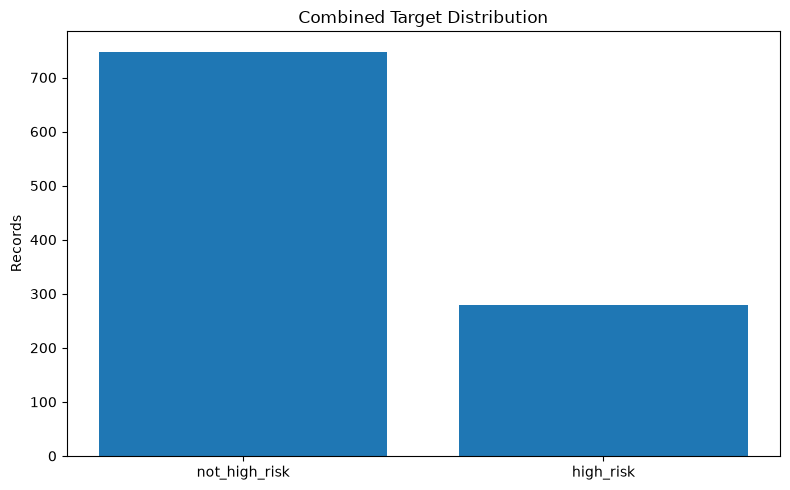

In [19]:
plt.figure(figsize=(8, 5))
target_counts = y_all.value_counts().sort_index()
plt.bar(
    ["not_high_risk", "high_risk"],
    target_counts.values,
)
plt.title("Combined Target Distribution")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

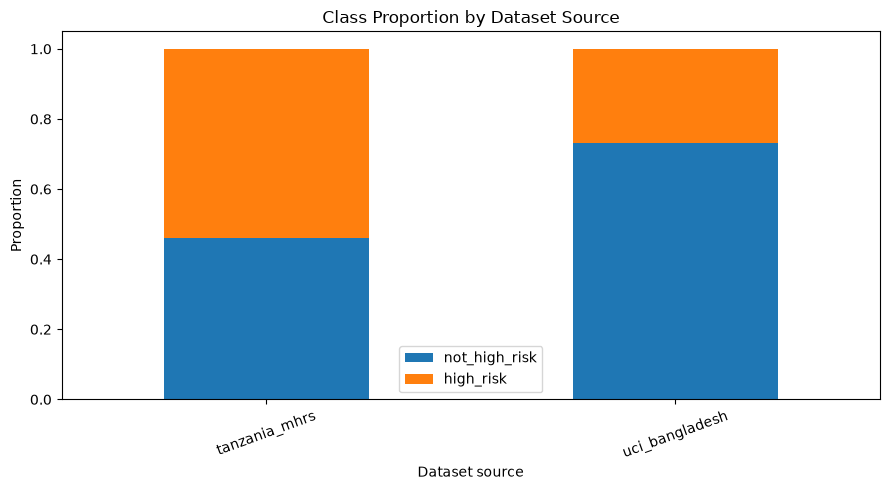

In [20]:
source_target = pd.crosstab(
    source_labels,
    y_all,
    normalize="index",
)

source_target.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
)
plt.title("Class Proportion by Dataset Source")
plt.xlabel("Dataset source")
plt.ylabel("Proportion")
plt.legend(["not_high_risk", "high_risk"])
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Step 19 — Held-out-source test

The largest source containing both classes is held out completely. This is stricter than a random row split because the model is tested on a different data domain.

In [21]:
eligible_holdouts = []

for source_name, group in pooled.groupby("dataset_source"):
    if group["target"].nunique() == 2:
        eligible_holdouts.append(
            (source_name, len(group))
        )

if not eligible_holdouts:
    raise RuntimeError(
        "No source contains both target classes."
    )

eligible_holdouts.sort(
    key=lambda item: item[1],
    reverse=True,
)

HELD_OUT_SOURCE = eligible_holdouts[0][0]

train_mask = source_labels != HELD_OUT_SOURCE
test_mask = source_labels == HELD_OUT_SOURCE

X_train = X_all.loc[train_mask].reset_index(drop=True)
y_train = y_all.loc[train_mask].reset_index(drop=True)
groups_train = record_groups.loc[train_mask].reset_index(drop=True)

X_test = X_all.loc[test_mask].reset_index(drop=True)
y_test = y_all.loc[test_mask].reset_index(drop=True)

if y_train.nunique() != 2 or y_test.nunique() != 2:
    raise RuntimeError(
        "Training and test sets must contain both classes."
    )

print("Held-out source:", HELD_OUT_SOURCE)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training sources:", sorted(
    source_labels.loc[train_mask].unique()
))

Held-out source: uci_bangladesh
Training rows: 13
Test rows: 1014
Training sources: ['tanzania_mhrs']


## Step 20 — Leakage-safe preprocessing and candidate models

In [22]:
linear_preprocessor = Pipeline([
    (
        "feature_engineering",
        MaternalGuardFeatureEngineer(
            tuple(SELECTED_BASE_FEATURES)
        ),
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True,
        ),
    ),
    ("scaler", RobustScaler()),
])

tree_preprocessor = Pipeline([
    (
        "feature_engineering",
        MaternalGuardFeatureEngineer(
            tuple(SELECTED_BASE_FEATURES)
        ),
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True,
        ),
    ),
])

CANDIDATE_MODELS = {
    "logistic_regression": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=SEED,
        )),
    ]),
    "random_forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=600,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "extra_trees": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=600,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "xgboost": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=500,
            max_depth=4,
            learning_rate=0.04,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.01,
            reg_lambda=3.0,
            random_state=SEED,
            tree_method="hist",
            n_jobs=1,
        )),
    ]),
}

print(list(CANDIDATE_MODELS))

['logistic_regression', 'random_forest', 'extra_trees', 'xgboost']


## Step 21 — Safety-focused evaluation metrics

In [23]:
from sklearn.metrics import make_scorer

def high_risk_recall(y_true, y_pred) -> float:
    return recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

def high_risk_precision(y_true, y_pred) -> float:
    return precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

def safety_score(y_true, y_pred) -> float:
    recall = high_risk_recall(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    balanced = balanced_accuracy_score(y_true, y_pred)
    return (
        0.55 * recall
        + 0.25 * f1
        + 0.20 * balanced
    )

SCORING = {
    "safety": make_scorer(safety_score),
    "roc_auc": "roc_auc",
    "balanced_accuracy": make_scorer(
        balanced_accuracy_score
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0,
    ),
    "high_risk_recall": make_scorer(
        high_risk_recall
    ),
    "high_risk_precision": make_scorer(
        high_risk_precision
    ),
}

cv = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)

## Step 22 — Cross-validated model benchmark

In [24]:
benchmark_rows = []

for model_name, estimator in CANDIDATE_MODELS.items():
    print("Evaluating:", model_name)

    result = cross_validate(
        estimator=estimator,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise",
    )

    benchmark_rows.append({
        "model": model_name,
        "safety_score": result["test_safety"].mean(),
        "roc_auc": result["test_roc_auc"].mean(),
        "balanced_accuracy": (
            result["test_balanced_accuracy"].mean()
        ),
        "f1": result["test_f1"].mean(),
        "high_risk_recall": (
            result["test_high_risk_recall"].mean()
        ),
        "high_risk_precision": (
            result["test_high_risk_precision"].mean()
        ),
        "fit_seconds": result["fit_time"].mean(),
    })

benchmark = (
    pd.DataFrame(benchmark_rows)
    .sort_values("safety_score", ascending=False)
    .reset_index(drop=True)
)

display(benchmark.round(4))

benchmark.to_csv(
    ARTIFACT_DIR / "model_benchmark.csv",
    index=False,
)

Evaluating: logistic_regression
Evaluating: random_forest
Evaluating: extra_trees
Evaluating: xgboost


,model,safety_score,roc_auc,balanced_accuracy,f1,high_risk_recall,high_risk_precision,fit_seconds
0,logistic_regression,0.6817,0.8,0.65,0.6667,0.7,0.7000,0.0951
1,extra_trees,0.5917,0.6,0.60,0.5667,0.6,0.6000,0.7260
2,random_forest,0.5717,0.3,0.50,0.5667,0.6,0.6000,1.4710
3,xgboost,0.5217,0.5,0.50,0.3667,0.6,0.2667,0.0708


## Step 23 — Hyperparameter tuning

In [25]:
best_family = benchmark.iloc[0]["model"]
search_estimator = clone(
    CANDIDATE_MODELS[best_family]
)

PARAMETER_SPACES = {
    "logistic_regression": {
        "model__C": loguniform(1e-3, 1e2),
        "model__class_weight": [
            None,
            "balanced",
        ],
    },
    "random_forest": {
        "model__n_estimators": randint(350, 1100),
        "model__max_depth": [
            None, 5, 8, 12, 16, 24
        ],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": [
            "sqrt", "log2", 0.6, 0.8, None
        ],
    },
    "extra_trees": {
        "model__n_estimators": randint(350, 1100),
        "model__max_depth": [
            None, 5, 8, 12, 16, 24
        ],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": [
            "sqrt", "log2", 0.6, 0.8, None
        ],
    },
    "xgboost": {
        "model__n_estimators": randint(250, 1000),
        "model__max_depth": randint(2, 9),
        "model__learning_rate": loguniform(
            0.01,
            0.20,
        ),
        "model__min_child_weight": randint(1, 12),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(
            0.65,
            0.35,
        ),
        "model__reg_alpha": loguniform(
            1e-5,
            2.0,
        ),
        "model__reg_lambda": loguniform(
            0.1,
            15.0,
        ),
    },
}

search = RandomizedSearchCV(
    estimator=search_estimator,
    param_distributions=PARAMETER_SPACES[
        best_family
    ],
    n_iter=SEARCH_ITERATIONS,
    scoring=SCORING,
    refit="safety",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise",
)

search.fit(
    X_train,
    y_train,
    groups=groups_train,
)

best_estimator = search.best_estimator_

print("Best family:", best_family)
print("Best CV safety:", search.best_score_)
print(json.dumps(
    search.best_params_,
    indent=2,
    default=str,
))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best family: logistic_regression
Best CV safety: 0.7716666666666667
{
  "model__C": 0.0745934328572655,
  "model__class_weight": null
}


## Step 24 — Out-of-fold threshold optimization

In [26]:
oof_probabilities = cross_val_predict(
    estimator=clone(best_estimator),
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

threshold_rows = []

for threshold in np.round(
    np.arange(0.10, 0.91, 0.01),
    2,
):
    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "threshold": float(threshold),
        "recall": recall_score(
            y_train,
            predictions,
            zero_division=0,
        ),
        "precision": precision_score(
            y_train,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_train,
            predictions,
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_train,
            predictions,
        ),
    })

threshold_table = pd.DataFrame(threshold_rows)

eligible = threshold_table[
    threshold_table["recall"]
    >= TARGET_HIGH_RISK_RECALL
].copy()

if len(eligible):
    selected_threshold_row = eligible.sort_values(
        ["f1", "precision", "threshold"],
        ascending=[False, False, False],
    ).iloc[0]
else:
    threshold_table["fallback_score"] = (
        0.70 * threshold_table["recall"]
        + 0.30 * threshold_table["f1"]
    )
    selected_threshold_row = (
        threshold_table
        .sort_values(
            "fallback_score",
            ascending=False,
        )
        .iloc[0]
    )

HIGH_RISK_THRESHOLD = float(
    selected_threshold_row["threshold"]
)

print("Selected threshold:", HIGH_RISK_THRESHOLD)
display(selected_threshold_row.to_frame("value"))

threshold_table.to_csv(
    ARTIFACT_DIR / "threshold_analysis.csv",
    index=False,
)

Selected threshold: 0.49


,value
threshold,0.490000
recall,1.000000
precision,0.583333
f1,0.736842
balanced_accuracy,0.583333


## Step 25 — Probability calibration

In [27]:
decision_model = clone(
    best_estimator
).fit(X_train, y_train)

calibration_splits = list(
    cv.split(
        X_train,
        y_train,
        groups=groups_train,
    )
)

probability_model = CalibratedClassifierCV(
    estimator=clone(best_estimator),
    method="sigmoid",
    cv=calibration_splits,
    ensemble=True,
    n_jobs=-1,
)

probability_model.fit(X_train, y_train)

print("Decision and probability models fitted.")

Decision and probability models fitted.


## Step 26 — Strict held-out-source evaluation

In [28]:
raw_test_probabilities = (
    decision_model.predict_proba(X_test)[:, 1]
)
calibrated_test_probabilities = (
    probability_model.predict_proba(X_test)[:, 1]
)

test_predictions = (
    raw_test_probabilities
    >= HIGH_RISK_THRESHOLD
).astype(int)

test_metrics = {
    "held_out_source": HELD_OUT_SOURCE,
    "rows": int(len(y_test)),
    "accuracy": accuracy_score(
        y_test,
        test_predictions,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        test_predictions,
    ),
    "f1": f1_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "high_risk_recall": recall_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "high_risk_precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        calibrated_test_probabilities,
    ),
    "log_loss": log_loss(
        y_test,
        calibrated_test_probabilities,
    ),
    "threshold": HIGH_RISK_THRESHOLD,
}

print(json.dumps(test_metrics, indent=2))
print()
print(classification_report(
    y_test,
    test_predictions,
    target_names=[
        "not_high_risk",
        "high_risk",
    ],
    zero_division=0,
))

{
  "held_out_source": "uci_bangladesh",
  "rows": 1014,
  "accuracy": 0.3826429980276134,
  "balanced_accuracy": 0.5560438798160774,
  "f1": 0.4469964664310954,
  "high_risk_recall": 0.9301470588235294,
  "high_risk_precision": 0.2941860465116279,
  "roc_auc": 0.6819357459965119,
  "log_loss": 0.7312751504809978,
  "threshold": 0.49
}

               precision    recall  f1-score   support

not_high_risk       0.88      0.18      0.30       742
    high_risk       0.29      0.93      0.45       272

     accuracy                           0.38      1014
    macro avg       0.59      0.56      0.37      1014
 weighted avg       0.72      0.38      0.34      1014



<Figure size 700x600 with 0 Axes>

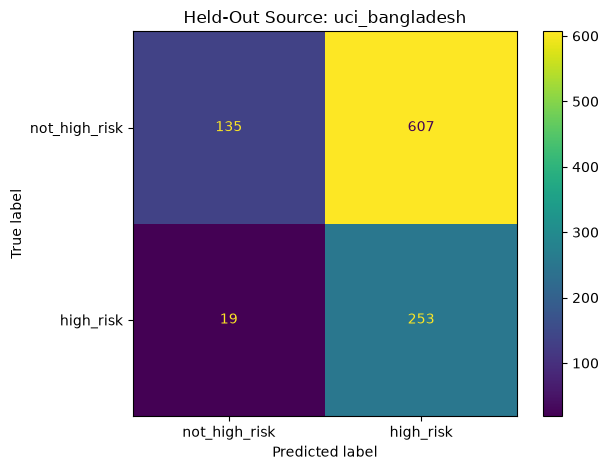

In [29]:
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=[
        "not_high_risk",
        "high_risk",
    ],
    values_format="d",
)
plt.title(
    f"Held-Out Source: {HELD_OUT_SOURCE}"
)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

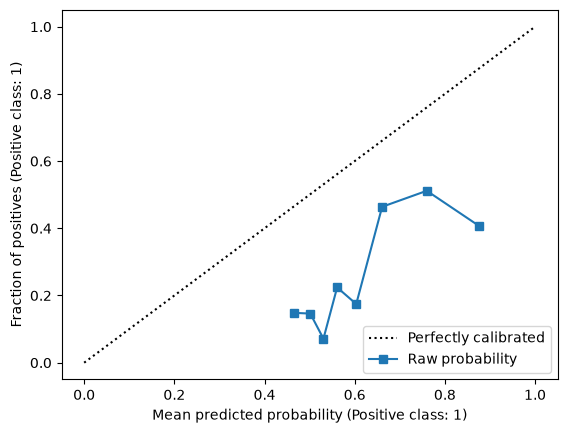

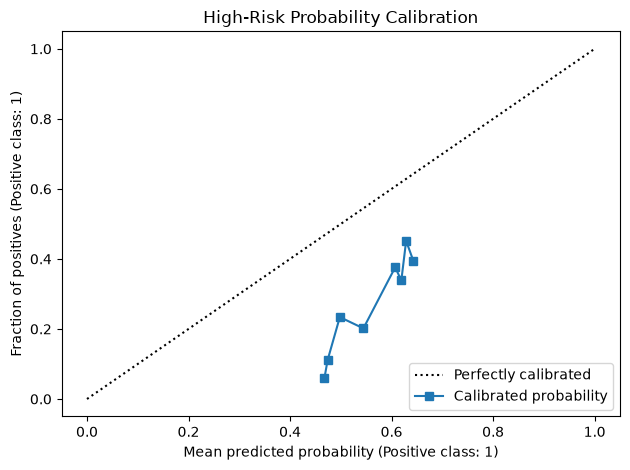

In [30]:
plt.figure(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    y_test,
    raw_test_probabilities,
    n_bins=8,
    strategy="quantile",
    name="Raw probability",
)
CalibrationDisplay.from_predictions(
    y_test,
    calibrated_test_probabilities,
    n_bins=8,
    strategy="quantile",
    name="Calibrated probability",
)
plt.title("High-Risk Probability Calibration")
plt.tight_layout()
plt.show()

## Step 27 — Leave-one-source-out validation

In [31]:
lodo_rows = []

for held_out_source in sorted(
    pooled["dataset_source"].unique()
):
    lodo_train_mask = (
        pooled["dataset_source"]
        != held_out_source
    )
    lodo_test_mask = (
        pooled["dataset_source"]
        == held_out_source
    )

    X_lodo_train = X_all.loc[lodo_train_mask]
    y_lodo_train = y_all.loc[lodo_train_mask]
    X_lodo_test = X_all.loc[lodo_test_mask]
    y_lodo_test = y_all.loc[lodo_test_mask]

    if (
        y_lodo_train.nunique() < 2
        or y_lodo_test.nunique() < 2
    ):
        continue

    estimator = clone(best_estimator)
    estimator.fit(X_lodo_train, y_lodo_train)

    probabilities = estimator.predict_proba(
        X_lodo_test
    )[:, 1]

    predictions = (
        probabilities >= HIGH_RISK_THRESHOLD
    ).astype(int)

    lodo_rows.append({
        "held_out_source": held_out_source,
        "rows": int(len(y_lodo_test)),
        "high_risk_recall": recall_score(
            y_lodo_test,
            predictions,
            zero_division=0,
        ),
        "high_risk_precision": precision_score(
            y_lodo_test,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_lodo_test,
            predictions,
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_lodo_test,
            predictions,
        ),
        "roc_auc": roc_auc_score(
            y_lodo_test,
            probabilities,
        ),
    })

lodo_results = pd.DataFrame(lodo_rows)
display(lodo_results.round(4))

lodo_results.to_csv(
    ARTIFACT_DIR / "leave_one_source_out.csv",
    index=False,
)

,held_out_source,rows,high_risk_recall,high_risk_precision,f1,balanced_accuracy,roc_auc
0,tanzania_mhrs,13,0.0000,0.0000,0.000,0.500,0.4524
1,uci_bangladesh,1014,0.9301,0.2942,0.447,0.556,0.6824


## Step 28 — Feature importance

In [32]:
importance = permutation_importance(
    estimator=decision_model,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=20 if FAST_MODE else 50,
    random_state=SEED,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": SELECTED_BASE_FEATURES,
        "importance_mean": (
            importance.importances_mean
        ),
        "importance_std": (
            importance.importances_std
        ),
    })
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(importance_df.round(4))

importance_df.to_csv(
    ARTIFACT_DIR / "permutation_importance.csv",
    index=False,
)

,feature,importance_mean,importance_std
0,age,0.1998,0.0168
1,body_temp,0.0044,0.0004
2,heart_rate,-0.0156,0.0031


## Step 29 — False-negative error analysis

In [33]:
error_analysis = X_test.copy()
error_analysis["true_class"] = (
    y_test.map({
        0: "not_high_risk",
        1: "high_risk",
    })
)
error_analysis["predicted_class"] = pd.Series(
    test_predictions
).map({
    0: "not_high_risk",
    1: "high_risk",
})
error_analysis["raw_high_risk_probability"] = (
    raw_test_probabilities
)
error_analysis[
    "calibrated_high_risk_probability"
] = calibrated_test_probabilities
error_analysis["critical_false_negative"] = (
    (y_test.to_numpy() == 1)
    & (test_predictions == 0)
)

error_analysis = error_analysis.sort_values(
    [
        "critical_false_negative",
        "raw_high_risk_probability",
    ],
    ascending=[False, True],
)

print(
    "Critical false negatives:",
    int(
        error_analysis[
            "critical_false_negative"
        ].sum()
    ),
)

display(error_analysis.head(30))

error_analysis.to_csv(
    ARTIFACT_DIR / "error_analysis.csv",
    index=False,
)

Critical false negatives: 19


,age,body_temp,heart_rate,true_class,predicted_class,raw_high_risk_probability,calibrated_high_risk_probability,critical_false_negative
285,13.0,38.333333,80.0,high_risk,not_high_risk,0.446646,0.489572,True
610,13.0,38.333333,80.0,high_risk,not_high_risk,0.446646,0.489572,True
1004,13.0,38.333333,80.0,high_risk,not_high_risk,0.446646,0.489572,True
199,17.0,38.888889,86.0,high_risk,not_high_risk,0.458601,0.493465,True
295,17.0,38.888889,86.0,high_risk,not_high_risk,0.458601,0.493465,True
390,17.0,38.888889,86.0,high_risk,not_high_risk,0.458601,0.493465,True
620,17.0,38.333333,86.0,high_risk,not_high_risk,0.458601,0.493465,True
973,17.0,38.888889,86.0,high_risk,not_high_risk,0.458601,0.493465,True
1006,17.0,38.888889,86.0,high_risk,not_high_risk,0.458601,0.493465,True
419,17.0,39.444444,80.0,high_risk,not_high_risk,0.478972,0.502730,True


## Step 30 — Refit final deployment models on all three datasets

The held-out metrics above remain the honest evaluation. Deployment artifacts are then refitted on the complete harmonized dataset.

In [34]:
final_decision_model = clone(
    best_estimator
).fit(X_all, y_all)

full_cv = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)

full_calibration_splits = list(
    full_cv.split(
        X_all,
        y_all,
        groups=record_groups,
    )
)

final_probability_model = CalibratedClassifierCV(
    estimator=clone(best_estimator),
    method="sigmoid",
    cv=full_calibration_splits,
    ensemble=True,
    n_jobs=-1,
)

final_probability_model.fit(X_all, y_all)

print("Final deployment models trained.")

Final deployment models trained.


## Step 31 — Save model, reports and model card

In [35]:
trained_at = datetime.now(
    timezone.utc
).isoformat()

bundle = {
    "model_name": "MaternalGuard",
    "model_version": MODEL_VERSION,
    "trained_at_utc": trained_at,
    "decision_model": final_decision_model,
    "probability_model": final_probability_model,
    "selected_base_features": (
        SELECTED_BASE_FEATURES
    ),
    "target_definition": {
        0: "not_high_risk",
        1: "high_risk",
    },
    "high_risk_threshold": (
        HIGH_RISK_THRESHOLD
    ),
    "selected_model_family": best_family,
    "selected_parameters": (
        search.best_params_
    ),
    "training_sources": sorted(
        pooled["dataset_source"]
        .unique()
        .tolist()
    ),
    "sanity_limits": SANITY_LIMITS,
}

joblib.dump(
    bundle,
    ARTIFACT_DIR
    / "maternalguard_bundle.joblib",
    compress=3,
)

pooled.to_parquet(
    PROCESSED_DIR
    / "harmonized_training_data.parquet",
    index=False,
)

benchmark.to_csv(
    ARTIFACT_DIR / "model_benchmark.csv",
    index=False,
)

model_card = {
    "model_name": "MaternalGuard",
    "version": MODEL_VERSION,
    "created_at_utc": trained_at,
    "intended_use": (
        "Research and hackathon maternal "
        "high-risk screening decision support."
    ),
    "prohibited_use": [
        "Autonomous diagnosis",
        "Treatment decisions",
        "Replacing clinician review",
        "Unvalidated clinical deployment",
    ],
    "datasets": DATASET_REGISTRY,
    "data_quality": data_quality_report,
    "target_harmonization": {
        "not_high_risk": (
            "low, medium/mid, normal, no"
        ),
        "high_risk": (
            "high, yes"
        ),
    },
    "selected_features": (
        SELECTED_BASE_FEATURES
    ),
    "split_method": (
        "Complete source holdout plus "
        "StratifiedGroupKFold by record signature."
    ),
    "held_out_test_metrics": test_metrics,
    "leave_one_source_out": (
        lodo_results.to_dict(orient="records")
    ),
    "high_risk_threshold": (
        HIGH_RISK_THRESHOLD
    ),
    "limitations": [
        "The datasets use different collection protocols.",
        "The binary target merges low and medium risk.",
        "Missingness patterns may differ by source.",
        "Sources are not from Pakistan.",
        "Prospective Pakistani clinical validation is required.",
        "The system must retain human clinician review.",
    ],
}

with open(
    ARTIFACT_DIR / "model_card.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_card,
        file,
        indent=2,
        default=str,
    )

shutil.copy(
    "maternalguard_features.py",
    ARTIFACT_DIR
    / "maternalguard_features.py",
)

print("Saved files:")
for file_path in sorted(
    ARTIFACT_DIR.iterdir()
):
    print("-", file_path.name)

Saved files:
- error_analysis.csv
- leave_one_source_out.csv
- maternalguard_bundle.joblib
- maternalguard_features.py
- model_benchmark.csv
- model_card.json
- permutation_importance.csv
- source_mapping_audit.csv
- threshold_analysis.csv


## Step 32 — Create reusable inference module

In [36]:
%%writefile /content/maternalguard/artifacts/inference.py
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, Mapping

import joblib
import pandas as pd

BUNDLE = joblib.load(
    Path(__file__).with_name(
        "maternalguard_bundle.joblib"
    )
)

EMERGENCY_FLAGS = {
    "heavy_bleeding",
    "convulsions",
    "loss_of_consciousness",
    "severe_breathing_difficulty",
}


def predict_maternal_risk(
    measurements: Mapping[str, float | int | None],
    symptom_flags: Mapping[str, bool] | None = None,
) -> Dict[str, Any]:
    features = BUNDLE[
        "selected_base_features"
    ]

    frame = pd.DataFrame([{
        feature: measurements.get(feature)
        for feature in features
    }])

    raw_probability = float(
        BUNDLE["decision_model"]
        .predict_proba(frame)[0, 1]
    )

    calibrated_probability = float(
        BUNDLE["probability_model"]
        .predict_proba(frame)[0, 1]
    )

    high_risk = (
        raw_probability
        >= BUNDLE["high_risk_threshold"]
    )

    active_emergency_flags = sorted(
        flag
        for flag in EMERGENCY_FLAGS
        if bool(
            (symptom_flags or {}).get(
                flag,
                False,
            )
        )
    )

    decision = (
        "high_risk"
        if high_risk
        else "not_high_risk"
    )
    decision_source = "ml_model"

    if active_emergency_flags:
        decision = "emergency_referral"
        decision_source = "clinical_rule_override"

    return {
        "model": BUNDLE["model_name"],
        "version": BUNDLE["model_version"],
        "decision": decision,
        "decision_source": decision_source,
        "high_risk_probability": (
            calibrated_probability
        ),
        "threshold": float(
            BUNDLE["high_risk_threshold"]
        ),
        "emergency_flags": (
            active_emergency_flags
        ),
        "notice": (
            "Research decision-support only. "
            "Qualified clinical review is required."
        ),
    }

Writing /content/maternalguard/artifacts/inference.py


## Step 33 — Test inference

In [37]:
import sys

sys.path.insert(
    0,
    str(ARTIFACT_DIR.resolve()),
)

from inference import predict_maternal_risk

sample = {
    feature: (
        float(
            pooled[feature]
            .dropna()
            .median()
        )
        if pooled[feature].notna().any()
        else None
    )
    for feature in SELECTED_BASE_FEATURES
}

result = predict_maternal_risk(
    measurements=sample,
    symptom_flags={
        "heavy_bleeding": False,
        "convulsions": False,
        "loss_of_consciousness": False,
        "severe_breathing_difficulty": False,
    },
)

print(json.dumps(result, indent=2))

{
  "model": "MaternalGuard",
  "version": "3.0.0",
  "decision": "not_high_risk",
  "decision_source": "ml_model",
  "high_risk_probability": 0.18280059475691643,
  "threshold": 0.49,
  "emergency_flags": [],
  "notice": "Research decision-support only. Qualified clinical review is required."
}


## Step 34 — FastAPI service

In [38]:
%%writefile /content/maternalguard/artifacts/app.py
from __future__ import annotations

from typing import Any, Dict

from fastapi import FastAPI
from pydantic import BaseModel, ConfigDict

from inference import predict_maternal_risk

app = FastAPI(
    title="MaaHifazat MaternalGuard API",
    version="3.0.0",
)


class ScreeningRequest(BaseModel):
    model_config = ConfigDict(extra="allow")

    measurements: Dict[
        str,
        float | int | None,
    ]
    symptom_flags: Dict[str, bool] = {}


@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": "MaternalGuard",
    }


@app.post("/predict")
def predict(request: ScreeningRequest) -> Dict[str, Any]:
    return predict_maternal_risk(
        measurements=request.measurements,
        symptom_flags=request.symptom_flags,
    )

Writing /content/maternalguard/artifacts/app.py


## Step 35 — Package and download all artifacts

In [39]:
requirements_text = f"""pandas=={pd.__version__}
numpy=={np.__version__}
scikit-learn=={sklearn.__version__}
xgboost=={xgboost.__version__}
joblib=={joblib.__version__}
fastapi
uvicorn
pydantic
"""

(
    ARTIFACT_DIR / "requirements.txt"
).write_text(
    requirements_text,
    encoding="utf-8",
)

readme_text = """# MaaHifazat MaternalGuard

Automatically trained from three public datasets:

- UCI Maternal Health Risk
- Tanzania MHRS
- Zenodo High-Risk Pregnancy

## Run API

```bash
pip install -r requirements.txt
uvicorn app:app --host 0.0.0.0 --port 8000
```

Research/hackathon prototype only.
"""

(
    ARTIFACT_DIR / "README.md"
).write_text(
    readme_text,
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "/content/MaternalGuard_Artifacts",
    "zip",
    root_dir=ARTIFACT_DIR,
)

print("Created:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Artifacts:", ARTIFACT_DIR)

Created: /content/MaternalGuard_Artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final checks before presenting

Report these results:

- Number of records from each source
- Selected common features
- High-risk recall
- High-risk false negatives
- F1-score
- Balanced accuracy
- ROC-AUC
- Held-out-source performance
- Leave-one-source-out results
- Probability calibration
- Dataset and geographic limitations

Do not claim that the model is clinically approved or ready for autonomous patient use.